# Assignment 1: Exploratory Data Analysis & Feature Engineering
## SCANIA Component X Dataset — Predictive Maintenance

**Objective:** Perform exploratory data analysis on the SCANIA Component X dataset, identify key patterns, clean the data, and engineer new features for future neural network models.

**Dataset:** Real-world multivariate time series from anonymized Scania truck engine components.  
**Source:** https://researchdata.se/en/catalogue/dataset/2024-34

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Data Loading and Initial Inspection

The SCANIA Component X dataset consists of multiple files:
- **Operational readouts** — sporadic, unevenly sampled time series of sensor data per vehicle (14 variables → 107 columns including vehicle_id and time_step)
- **Specifications** — 8 categorical truck specifications (e.g., engine type, wheel configuration — anonymized)
- **Time-to-event (TTE)** — repair records: `in_study_repair` (0 = no repair, 1 = component X was repaired) and `length_of_study_time_step` (total observation period)

**Important note on labels:**
- In the **training set**, the label is binary: `in_study_repair` (0/1) — did the component fail during the study?
- In the **validation/test sets**, labels are multi-class (0-4) based on proximity to failure:
  - Class 0: >48 time units before failure (safe)
  - Class 1: 24–48 time units before failure
  - Class 2: 12–24 time units before failure  
  - Class 3: 6–12 time units before failure
  - Class 4: 0–6 time units before failure (imminent!)

**Sensor types (14 variables, 105 data columns):**
- **6 histogram variables:** 167 (10 bins), 272 (10 bins), 291 (11 bins), 158 (10 bins), 459 (20 bins), 397 (36 bins) — these represent distributions of a measurement across different conditions (e.g., distance driven at different temperature ranges)
- **8 numerical counters:** 171_0, 666_0, 427_0, 837_0, 309_0, 835_0, 370_0, 100_0 — mostly accumulative values (always increasing over time, like an odometer)

We sample 50,000 rows from the operational readouts for efficient analysis.

In [2]:
# Load all dataset files
specs = pd.read_csv('data/train_specifications.csv')
tte = pd.read_csv('data/train_tte.csv')

# Sample operational readouts (full file is ~1.2GB)
# Read header first, then sample rows
total_rows = sum(1 for _ in open('data/train_operational_readouts.csv')) - 1
sample_size = min(50000, total_rows)
if total_rows > sample_size:
    skip_idx = sorted(np.random.RandomState(42).choice(range(1, total_rows + 1), size=total_rows - sample_size, replace=False))
    readouts = pd.read_csv('data/train_operational_readouts.csv', skiprows=skip_idx)
else:
    readouts = pd.read_csv('data/train_operational_readouts.csv')

# Training data label: 'in_study_repair' from TTE
# 1 = Component X was repaired (failed) during the study period
# 0 = No repair occurred (healthy OR censored — we don't know what happened after the study ended)
# Note: This is NOT the same as the 5-class labels in validation/test sets
print(f"Operational readouts: {readouts.shape}")
print(f"Specifications:       {specs.shape}")
print(f"Time-to-event:        {tte.shape}")
print(f"\nRepair distribution (in_study_repair):")
print(tte['in_study_repair'].value_counts())
print(f"\nImbalance: {tte['in_study_repair'].value_counts()[0]} healthy/censored vs {tte['in_study_repair'].value_counts()[1]} failed ({tte['in_study_repair'].mean()*100:.1f}% failure rate)")

Operational readouts: (50000, 107)
Specifications:       (23550, 9)
Time-to-event:        (23550, 3)

Repair distribution (in_study_repair):
in_study_repair
0    21278
1     2272
Name: count, dtype: int64

Imbalance: 21278 healthy/censored vs 2272 failed (9.6% failure rate)


In [3]:
# General info about the operational readouts
print("=== Operational Readouts Info ===")
print(readouts.info())
print("\n=== First 5 rows ===")
readouts.head()

=== Operational Readouts Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 107 entries, vehicle_id to 397_35
dtypes: float64(106), int64(1)
memory usage: 40.8 MB
None

=== First 5 rows ===


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,0,28.0,542490.0,21063.0,21590525.0,3280.0,NaN,NaN,NaN,NaN,...,212929.0,25143.0,3156.0,16.0,2074.0,283016.0,389593.0,127362.0,21347.0,458.0
1,0,44.0,911940.0,34302.0,35673804.0,6625.0,NaN,NaN,NaN,NaN,...,323368.0,33891.0,4759.0,24.0,3177.0,430331.0,535958.0,161937.0,25060.0,462.0
2,0,65.0,1364325.0,51725.0,52731900.0,10049.0,NaN,NaN,NaN,NaN,...,485523.0,42959.0,6441.0,28.0,4685.0,593759.0,722222.0,204569.0,29496.0,471.0
3,0,71.6,1529925.0,58452.0,59066999.0,10522.0,NaN,NaN,NaN,NaN,...,534239.0,46084.0,7038.0,28.0,5441.0,643939.0,777143.0,219605.0,31033.0,471.0
4,0,97.2,2158785.0,80350.0,83089177.0,11963.0,NaN,NaN,NaN,NaN,...,766383.0,58849.0,9746.0,136.0,8544.0,892762.0,1035227.0,274218.0,37417.0,585.0


In [4]:
# Statistical description of numerical features
readouts.describe()

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
count,50000.000000,50000.000000,5.000000e+04,4.999800e+04,4.969100e+04,4.999700e+04,4.981000e+04,4.981000e+04,4.981000e+04,4.981000e+04,...,4.997800e+04,4.997800e+04,4.997800e+04,4.997800e+04,4.997800e+04,4.997800e+04,4.997800e+04,4.997800e+04,4.997800e+04,49978.000000
mean,7134.187140,151.068632,3.556247e+06,1.474446e+05,1.363560e+08,5.589452e+04,1.983310e+04,6.878682e+06,1.841524e+07,1.546955e+07,...,1.718069e+06,1.854617e+05,3.474340e+06,3.494114e+03,1.959772e+04,7.724955e+05,1.796404e+06,5.620110e+05,1.986332e+05,3409.317019
std,4638.496949,101.735120,2.992434e+06,1.750000e+05,1.090805e+08,9.854288e+04,5.704899e+04,5.748556e+06,1.677621e+07,1.666603e+07,...,1.726750e+06,5.272683e+05,3.423194e+08,3.002022e+05,3.012319e+05,1.152799e+06,2.261238e+06,7.102178e+05,3.892855e+05,13680.620955
min,0.000000,0.000000,3.000000e+01,0.000000e+00,5.027000e+03,0.000000e+00,0.000000e+00,2.124000e+04,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,3010.000000,68.600000,1.237365e+06,3.299475e+04,5.190099e+07,3.736000e+03,1.950250e+03,2.684210e+06,6.848121e+06,5.251683e+06,...,4.737480e+05,4.346650e+04,6.644250e+03,4.800000e+01,4.643000e+03,1.537062e+05,3.603110e+05,1.122680e+05,2.132125e+04,113.000000
50%,6689.500000,135.000000,2.788350e+06,8.989250e+04,1.113105e+08,2.108000e+04,8.617000e+03,5.454938e+06,1.415532e+07,1.115081e+07,...,1.204706e+06,1.040170e+05,1.833500e+04,1.960000e+02,1.080750e+04,4.194720e+05,1.057154e+06,3.161140e+05,6.957250e+04,517.000000
75%,10878.000000,218.400000,5.157731e+06,2.010872e+05,1.948746e+08,6.971500e+04,2.392600e+04,9.500813e+06,2.499136e+07,2.010880e+07,...,2.438014e+06,2.169218e+05,4.548250e+04,6.680000e+02,2.087550e+04,9.474440e+05,2.366530e+06,7.252880e+05,1.993935e+05,2239.000000
max,15723.000000,501.400000,2.658897e+07,5.860409e+06,9.100830e+08,6.518059e+06,7.526577e+06,6.490608e+07,3.012964e+08,3.596875e+08,...,3.481968e+07,5.055800e+07,3.422584e+10,3.355794e+07,3.358201e+07,3.398308e+07,3.462423e+07,8.810698e+06,7.042103e+06,539044.000000


In [5]:
# Check missing values across all files
print("=== Missing Values: Operational Readouts ===")
missing_readouts = readouts.isnull().sum()
missing_readouts = missing_readouts[missing_readouts > 0]
if len(missing_readouts) > 0:
    print(missing_readouts.sort_values(ascending=False))
else:
    print("No missing values found.")

print(f"\n=== Missing Values: Specifications ===")
print(f"{specs.isnull().sum().sum()} total missing")

print(f"\n=== Missing Values: TTE ===")
print(f"{tte.isnull().sum().sum()} total missing")

=== Missing Values: Operational Readouts ===
291_10    460
291_4     460
291_2     460
291_1     460
291_0     460
         ... 
272_9      16
837_0       3
309_0       2
666_0       2
835_0       1
Length: 104, dtype: int64

=== Missing Values: Specifications ===
0 total missing

=== Missing Values: TTE ===
0 total missing


In [6]:
# Inspect specifications and TTE
print("=== Specifications ===")
print(specs.head())
print("\n=== TTE (Time-to-Event) ===")
print(tte.head())
print(f"\n=== TTE Statistics ===")
print(tte.describe())

=== Specifications ===
   vehicle_id Spec_0 Spec_1 Spec_2 Spec_3 Spec_4 Spec_5 Spec_6 Spec_7
0           0   Cat0   Cat0   Cat0   Cat0   Cat0   Cat0   Cat0   Cat0
1           2   Cat0   Cat1   Cat1   Cat0   Cat0   Cat0   Cat0   Cat1
2           3   Cat0   Cat1   Cat1   Cat1   Cat0   Cat0   Cat0   Cat1
3           4   Cat0   Cat0   Cat2   Cat1   Cat0   Cat0   Cat0   Cat1
4           5   Cat0   Cat2   Cat2   Cat0   Cat0   Cat0   Cat0   Cat1

=== TTE (Time-to-Event) ===
   vehicle_id  length_of_study_time_step  in_study_repair
0           0                      510.0                0
1           2                      281.8                0
2           3                      293.4                0
3           4                      210.0                0
4           5                      360.4                0

=== TTE Statistics ===
         vehicle_id  length_of_study_time_step  in_study_repair
count  23550.000000               23550.000000     23550.000000
mean   16851.663185         

In [7]:
# Merge all data into a single DataFrame
# Merge readouts with TTE (contains repair label)
df = readouts.merge(tte, on='vehicle_id', how='left')

# Rename in_study_repair to class_label for consistency
# Note: In training data this is binary (0=healthy/censored, 1=failed)
# In validation/test data, class_label is multi-class (0-4) based on time-to-failure
df = df.rename(columns={'in_study_repair': 'class_label'})

# Encode specifications and merge
specs_encoded = specs.copy()
for col in specs.columns:
    if col != 'vehicle_id':
        le = LabelEncoder()
        specs_encoded[col] = le.fit_transform(specs[col].astype(str))
df = df.merge(specs_encoded, on='vehicle_id', how='left')

print(f"Merged dataset shape: {df.shape}")
print(f"Columns: {list(df.columns[:10])} ... {list(df.columns[-10:])}")
df.head()

Merged dataset shape: (50000, 117)
Columns: ['vehicle_id', 'time_step', '171_0', '666_0', '427_0', '837_0', '167_0', '167_1', '167_2', '167_3'] ... ['length_of_study_time_step', 'class_label', 'Spec_0', 'Spec_1', 'Spec_2', 'Spec_3', 'Spec_4', 'Spec_5', 'Spec_6', 'Spec_7']


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,length_of_study_time_step,class_label,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,0,28.0,542490.0,21063.0,21590525.0,3280.0,NaN,NaN,NaN,NaN,...,510.0,0,0,0,0,0,0,0,0,0
1,0,44.0,911940.0,34302.0,35673804.0,6625.0,NaN,NaN,NaN,NaN,...,510.0,0,0,0,0,0,0,0,0,0
2,0,65.0,1364325.0,51725.0,52731900.0,10049.0,NaN,NaN,NaN,NaN,...,510.0,0,0,0,0,0,0,0,0,0
3,0,71.6,1529925.0,58452.0,59066999.0,10522.0,NaN,NaN,NaN,NaN,...,510.0,0,0,0,0,0,0,0,0,0
4,0,97.2,2158785.0,80350.0,83089177.0,11963.0,NaN,NaN,NaN,NaN,...,510.0,0,0,0,0,0,0,0,0,0


---
## 2. Timestamp Processing

The `time_step` column represents the **number of time units the vehicle and Component X have been in operation** since the start of use. It is NOT a calendar date or clock time — it functions like an odometer for time.

Key characteristics:
- Readouts are **sporadic and unevenly sampled** — different vehicles have different reading frequencies
- Each vehicle has its own timeline starting from 0
- We cannot derive real hours, days, or weekends from this data

We will:
- Sort data by vehicle and time step
- Create a **lifecycle progress** feature (0.0 = first reading, 1.0 = last reading)
- Create **binned temporal features** from time_step for the assignment requirement (note: these are artificial bins, not real time-of-day)
- Track observation sequence number per vehicle

In [8]:
# Sort by vehicle_id and time_step
df = df.sort_values(['vehicle_id', 'time_step']).reset_index(drop=True)

# Analyze time_step distribution
print("=== time_step statistics ===")
print(df['time_step'].describe())
print(f"\nUnique vehicles: {df['vehicle_id'].nunique()}")
print(f"Observations per vehicle (mean): {df.groupby('vehicle_id').size().mean():.1f}")
print(f"Observations per vehicle (min/max): {df.groupby('vehicle_id').size().min()} / {df.groupby('vehicle_id').size().max()}")

=== time_step statistics ===
count    50000.000000
mean       151.068632
std        101.735120
min          0.000000
25%         68.600000
50%        135.000000
75%        218.400000
max        501.400000
Name: time_step, dtype: float64

Unique vehicles: 10231
Observations per vehicle (mean): 4.9
Observations per vehicle (min/max): 1 / 29


In [9]:
# Create temporal features from time_step
# Normalize time_step per vehicle to [0, 1] range (lifecycle progress)
# This is meaningful: 0.0 = beginning of component's life, 1.0 = end of observation
df['lifecycle_progress'] = df.groupby('vehicle_id')['time_step'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0.5
)

# Create binned features from time_step (for assignment requirement)
# NOTE: These are ARTIFICIAL bins — time_step represents operational time units,
# NOT clock time. "hour_bin" and "day_bin" are just cyclic bins of the time_step value.
# They do NOT correspond to actual hours or days of the week.
df['hour_bin'] = (df['time_step'] % 24).astype(int)
df['day_bin'] = (df['time_step'] % 168 // 24).astype(int)  # 168 = 24*7
df['is_weekend'] = (df['day_bin'] >= 5).astype(int)

# Observation sequence number within each vehicle (genuinely useful)
df['obs_number'] = df.groupby('vehicle_id').cumcount()

print("New temporal features created:")
print(df[['vehicle_id', 'time_step', 'lifecycle_progress', 'hour_bin', 'day_bin', 'is_weekend', 'obs_number']].head(10))

New temporal features created:
   vehicle_id  time_step  lifecycle_progress  hour_bin  day_bin  is_weekend  \
0           0       28.0            0.000000         4        1           0   
1           0       44.0            0.035682        20        1           0   
2           0       65.0            0.082516        17        2           0   
3           0       71.6            0.097235        23        2           0   
4           0       97.2            0.154326         1        4           0   
5           0      125.8            0.218109         5        5           1   
6           0      159.2            0.292596        15        6           1   
7           0      169.8            0.316236         1        0           0   
8           0      197.0            0.376896         5        1           0   
9           0      210.4            0.406780        18        1           0   

   obs_number  
0           0  
1           1  
2           2  
3           3  
4           4  
5  

---
## 3. Visualization and Distribution Analysis

We analyze the data through:
1. **Correlation matrix** — identify features most correlated with component failure
2. **Feature distributions** — histograms to spot skewness and outliers
3. **Time series plots** — operational readouts over time with rolling averages
4. **Temporal patterns** — mean values by hour/day bins
5. **Class distribution** — healthy vs failed components

Top 20 features most correlated with class_label (absolute):
length_of_study_time_step    0.127404
Spec_0                       0.078741
459_15                       0.068999
Spec_3                       0.067931
Spec_6                       0.066302
time_step                    0.059704
vehicle_id                   0.059677
272_1                        0.051125
Spec_7                       0.049989
167_2                        0.049023
167_3                        0.046201
291_4                        0.044401
Spec_1                       0.043304
158_0                        0.042044
291_3                        0.039017
459_14                       0.036886
100_0                        0.033192
167_4                        0.033032
291_5                        0.032346
167_9                        0.031102
Name: class_label, dtype: float64


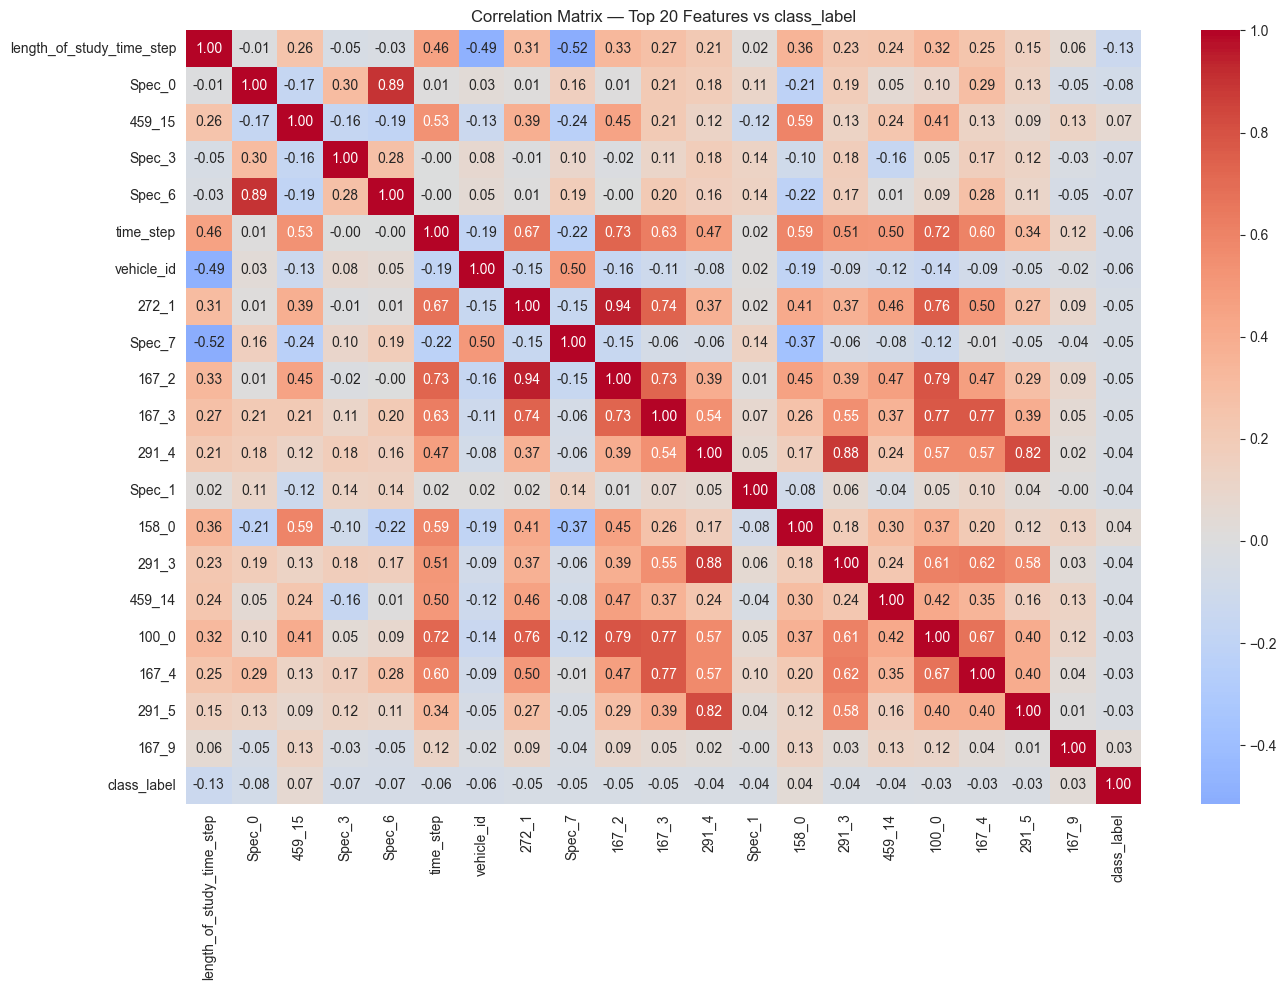

In [10]:
# 3.1 Correlation matrix — focus on features most correlated with class_label
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation with class_label
if 'class_label' in df.columns:
    corr_with_target = df[numeric_cols].corr()['class_label'].drop('class_label').abs().sort_values(ascending=False)
    top_features = corr_with_target.head(20).index.tolist()
    
    print("Top 20 features most correlated with class_label (absolute):")
    print(corr_with_target.head(20))
    
    # Heatmap of top correlated features
    fig, ax = plt.subplots(figsize=(14, 10))
    corr_matrix = df[top_features + ['class_label']].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
    ax.set_title('Correlation Matrix — Top 20 Features vs class_label')
    plt.tight_layout()
    plt.show()

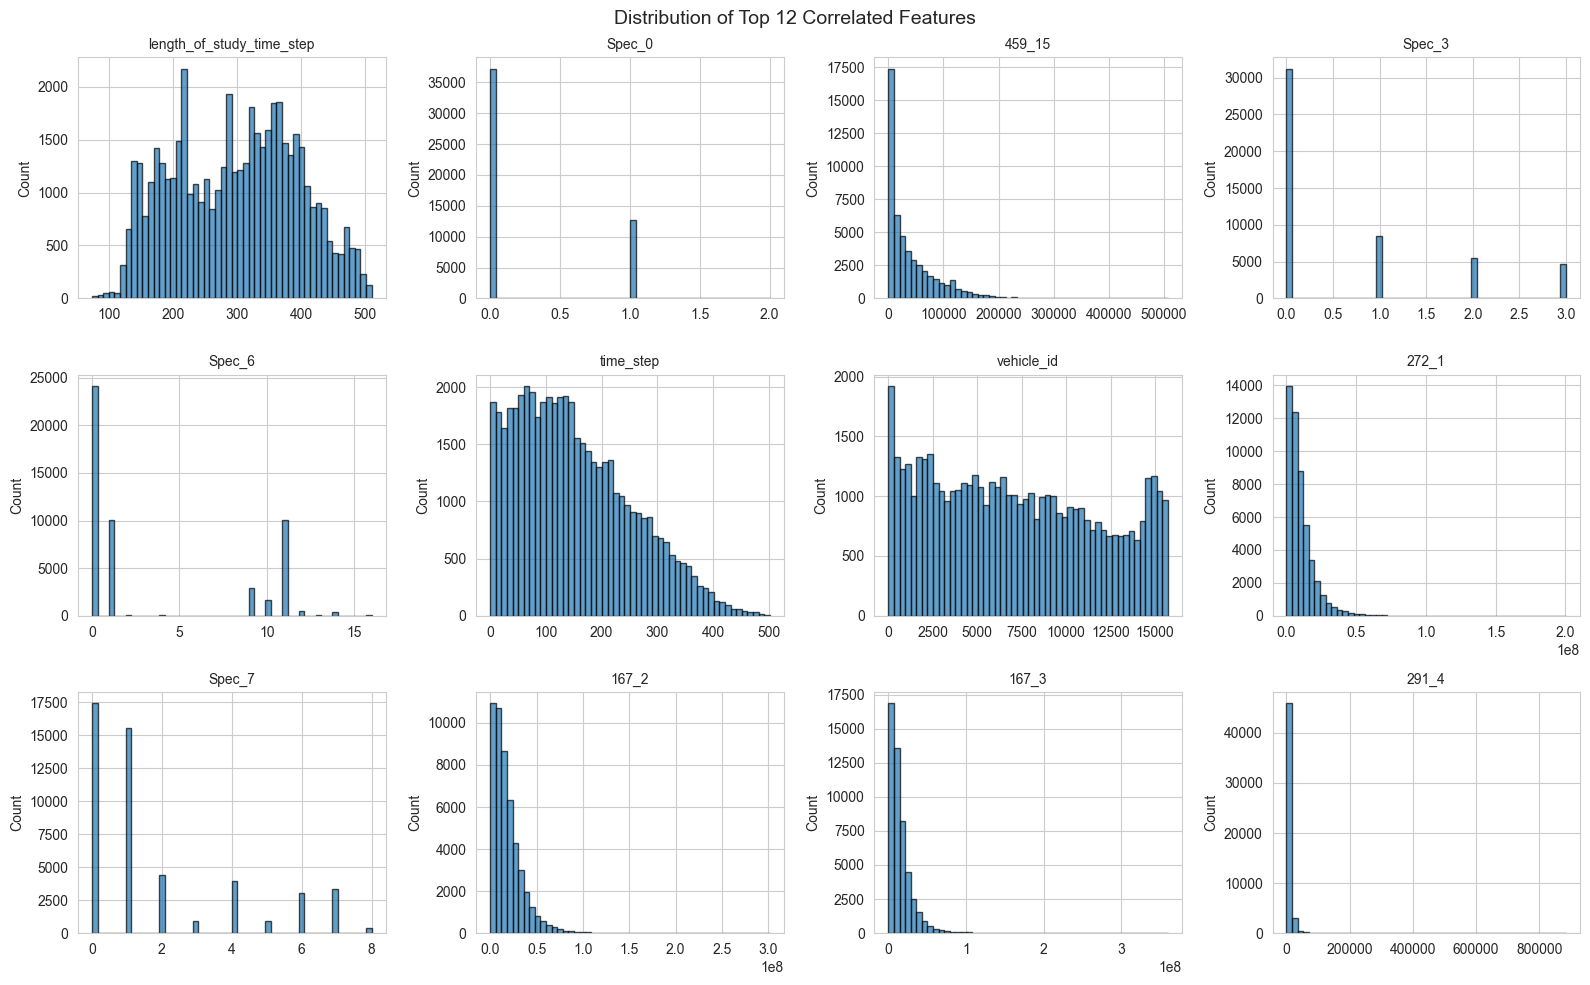

In [11]:
# 3.2 Histograms of top 12 features
top12 = corr_with_target.head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, col in enumerate(top12):
    ax = axes[i // 4, i % 4]
    df[col].hist(bins=50, ax=ax, alpha=0.7, edgecolor='black')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Count')
plt.suptitle('Distribution of Top 12 Correlated Features', fontsize=14)
plt.tight_layout()
plt.show()

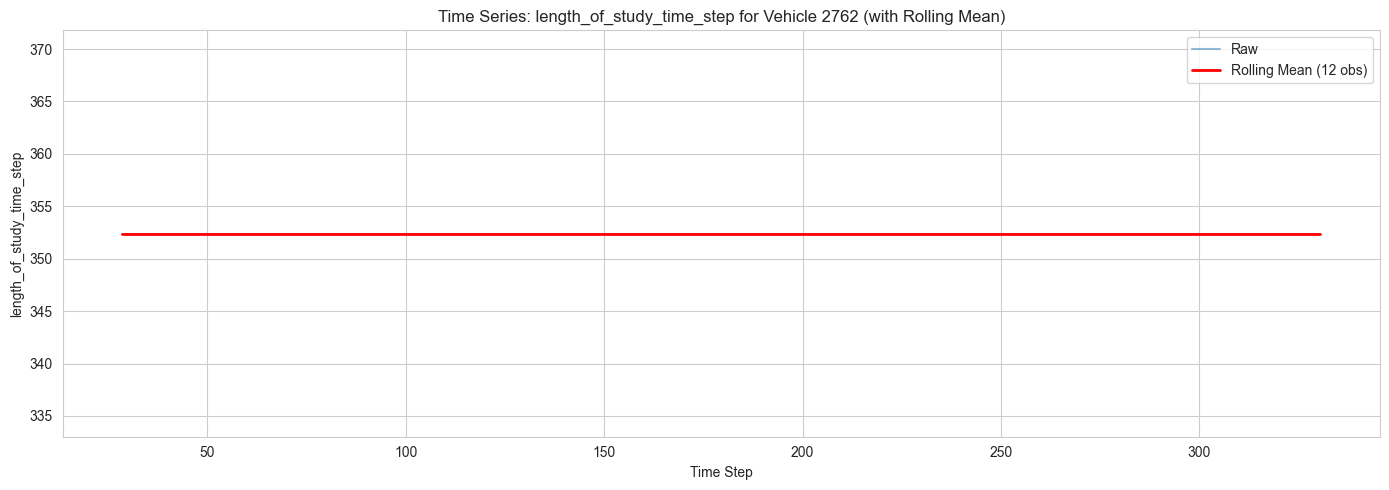

In [12]:
# 3.3 Time series plot for a sample vehicle with rolling mean
# Pick a vehicle with many observations
vehicle_counts = df.groupby('vehicle_id').size().sort_values(ascending=False)
sample_vehicle = vehicle_counts.index[0]
vehicle_data = df[df['vehicle_id'] == sample_vehicle].copy()

# Plot the top correlated feature over time
feature_to_plot = top12[0]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(vehicle_data['time_step'], vehicle_data[feature_to_plot], alpha=0.5, label='Raw')
ax.plot(vehicle_data['time_step'], vehicle_data[feature_to_plot].rolling(window=12, min_periods=1).mean(),
        color='red', linewidth=2, label='Rolling Mean (12 obs)')
ax.set_xlabel('Time Step')
ax.set_ylabel(feature_to_plot)
ax.set_title(f'Time Series: {feature_to_plot} for Vehicle {sample_vehicle} (with Rolling Mean)')
ax.legend()
plt.tight_layout()
plt.show()

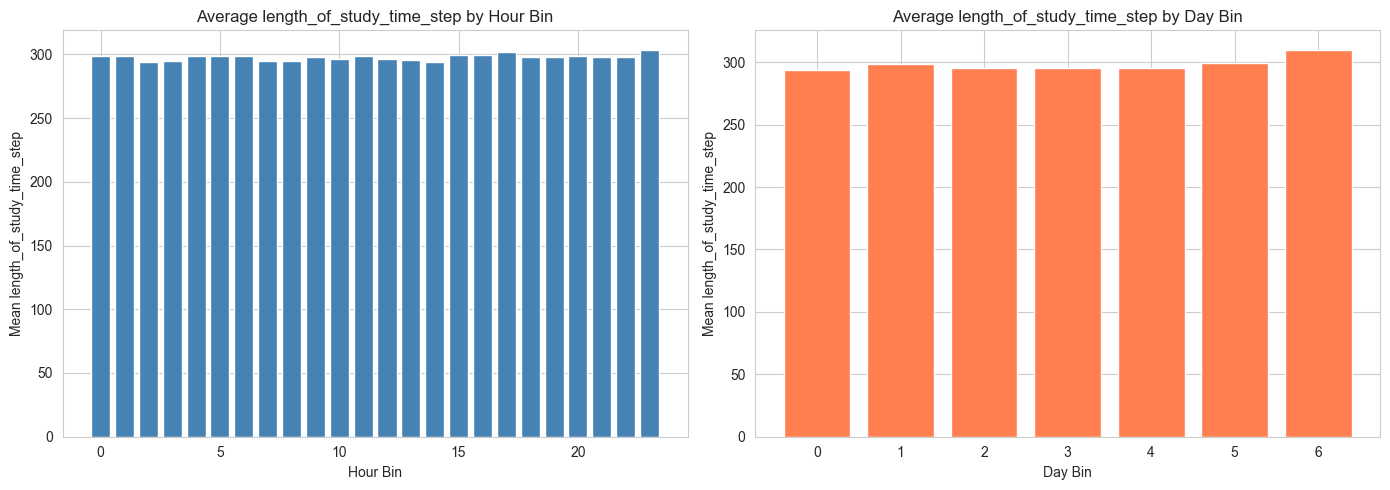

In [13]:
# 3.4 Mean feature values by hour_bin and day_bin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By hour bin
hourly_avg = df.groupby('hour_bin')[feature_to_plot].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color='steelblue')
axes[0].set_xlabel('Hour Bin')
axes[0].set_ylabel(f'Mean {feature_to_plot}')
axes[0].set_title(f'Average {feature_to_plot} by Hour Bin')

# By day bin
daily_avg = df.groupby('day_bin')[feature_to_plot].mean()
axes[1].bar(daily_avg.index, daily_avg.values, color='coral')
axes[1].set_xlabel('Day Bin')
axes[1].set_ylabel(f'Mean {feature_to_plot}')
axes[1].set_title(f'Average {feature_to_plot} by Day Bin')

plt.tight_layout()
plt.show()

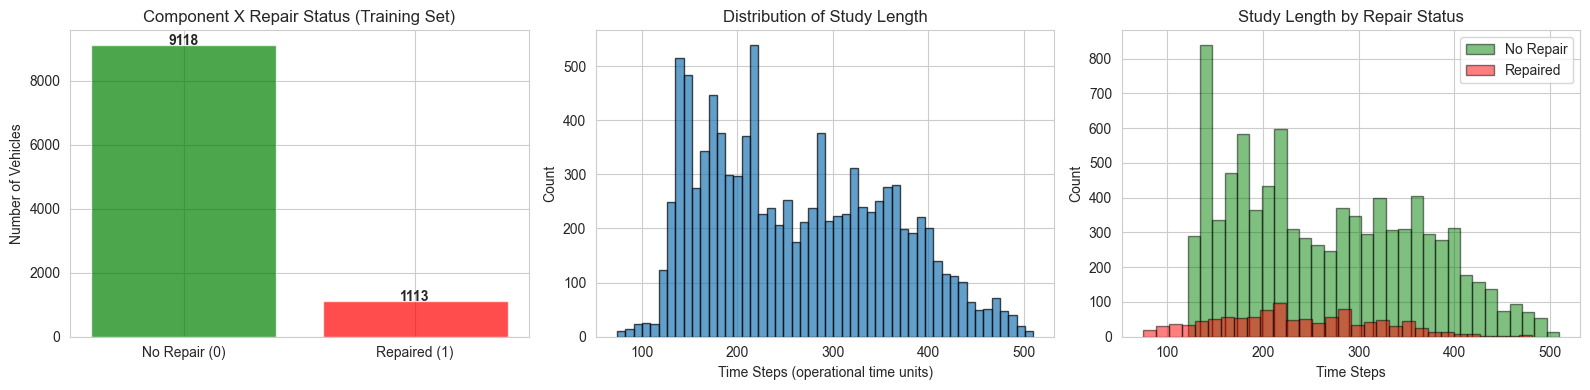


Repair rate: 1113 / 10231 = 10.9%
Imbalance ratio: 8.2:1 (no-repair : repaired)

Note: In validation/test sets, labels are 5-class (0-4) based on time window before failure.
Class 0 = >48 time units before failure, Class 4 = 0-6 time units (imminent failure).


In [14]:
# 3.5 Repair distribution and Time-to-Event
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Repair distribution (per vehicle) — training set is binary (0/1)
class_counts = df.drop_duplicates('vehicle_id')['class_label'].value_counts().sort_index()
axes[0].bar(['No Repair (0)', 'Repaired (1)'], [class_counts.get(0, 0), class_counts.get(1, 0)],
            color=['green', 'red'], alpha=0.7)
axes[0].set_title('Component X Repair Status (Training Set)')
axes[0].set_ylabel('Number of Vehicles')
for i, v in enumerate([class_counts.get(0, 0), class_counts.get(1, 0)]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# TTE distribution
tte_per_vehicle = df.drop_duplicates('vehicle_id')[['length_of_study_time_step', 'class_label']]
axes[1].hist(tte_per_vehicle['length_of_study_time_step'].dropna(), bins=50, alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Study Length')
axes[1].set_xlabel('Time Steps (operational time units)')
axes[1].set_ylabel('Count')

# TTE by repair status
for label, color, name in [(0, 'green', 'No Repair'), (1, 'red', 'Repaired')]:
    subset = tte_per_vehicle[tte_per_vehicle['class_label'] == label]['length_of_study_time_step']
    axes[2].hist(subset.dropna(), bins=30, alpha=0.5, color=color, label=name, edgecolor='black')
axes[2].set_title('Study Length by Repair Status')
axes[2].set_xlabel('Time Steps')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nRepair rate: {class_counts.get(1, 0)} / {class_counts.sum()} = {class_counts.get(1, 0)/class_counts.sum()*100:.1f}%")
print(f"Imbalance ratio: {class_counts.get(0, 0) / max(class_counts.get(1, 1), 1):.1f}:1 (no-repair : repaired)")
print(f"\nNote: In validation/test sets, labels are 5-class (0-4) based on time window before failure.")
print("Class 0 = >48 time units before failure, Class 4 = 0-6 time units (imminent failure).")

---
## 4. Handling Missing Values and Outliers

**Strategy:**
- **Missing values:** For time-series features, we use forward-fill within each vehicle (carrying the last known reading), then backward-fill for any remaining NaNs at the start. Remaining NaNs are filled with the column median.
- **Outliers:** We use the IQR method (values beyond 1.5 * IQR from Q1/Q3) to detect outliers. Rather than removing them (which could discard important failure signals), we cap them at the IQR boundaries.

Columns with missing values: 104
        Missing Count  Missing %
291_10            460      0.920
291_4             460      0.920
291_2             460      0.920
291_1             460      0.920
291_0             460      0.920
291_5             460      0.920
291_6             460      0.920
291_7             460      0.920
291_8             460      0.920
291_9             460      0.920
291_3             460      0.920
459_10            353      0.706
459_12            353      0.706
459_19            353      0.706
459_18            353      0.706
459_17            353      0.706
459_16            353      0.706
459_15            353      0.706
459_14            353      0.706
459_13            353      0.706


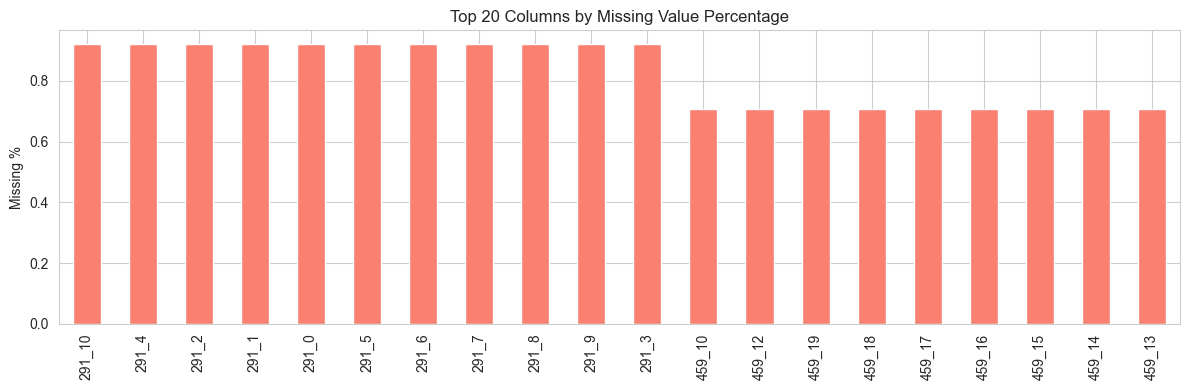

In [15]:
# 4.1 Detailed missing value analysis
missing_before = df.isnull().sum()
missing_pct = (missing_before / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing_before, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_summary) > 0:
    print(f"Columns with missing values: {len(missing_summary)}")
    print(missing_summary.head(20))
    
    # Visualize missing values
    fig, ax = plt.subplots(figsize=(12, 4))
    missing_summary.head(20)['Missing %'].plot(kind='bar', ax=ax, color='salmon')
    ax.set_title('Top 20 Columns by Missing Value Percentage')
    ax.set_ylabel('Missing %')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

In [16]:
# 4.2 Fill missing values
# Strategy: forward-fill within each vehicle, then backward-fill, then median
sensor_cols = [c for c in df.columns if c not in ['vehicle_id', 'time_step', 'class_label',
               'length_of_study_time_step', 'in_study_repair', 'lifecycle_progress',
               'hour_bin', 'day_bin', 'is_weekend', 'obs_number'] and not c.startswith('Spec_')]

# Forward-fill then backward-fill within each vehicle
df[sensor_cols] = df.groupby('vehicle_id')[sensor_cols].transform(
    lambda x: x.ffill().bfill()
)

# Fill any remaining NaNs with column median
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

# Fill class_label NaNs (vehicles not in labels file)
if df['class_label'].isnull().any():
    df['class_label'] = df['class_label'].fillna(0)  # Assume healthy if no label

missing_after = df.isnull().sum().sum()
print(f"Missing values after imputation: {missing_after}")

Missing values after imputation: 0


Features with outliers: 105

Top 15 features by outlier count:
459_16    9563
370_0     9540
167_9     8853
309_0     7968
272_3     7636
272_7     7090
459_18    7047
272_6     6992
167_8     6902
397_35    6552
459_19    6536
397_29    5772
397_15    5718
158_9     5686
459_17    5631
dtype: int64


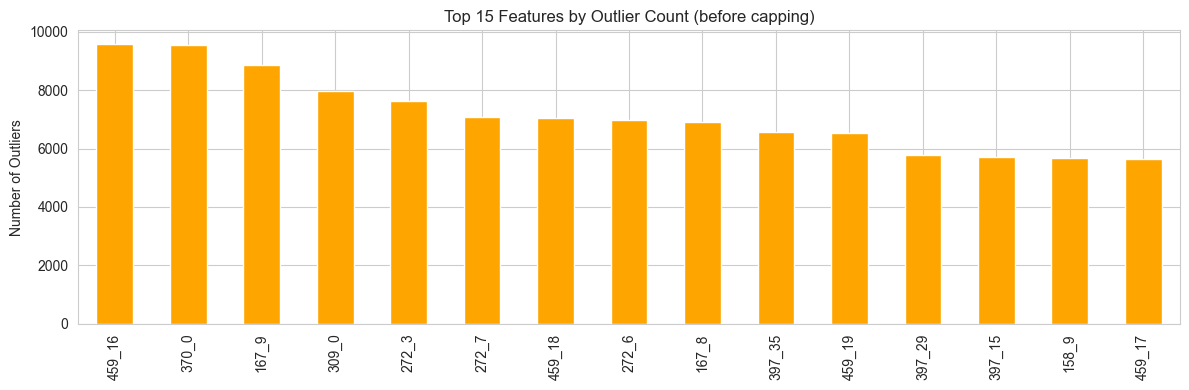

In [17]:
# 4.3 Outlier detection and capping using IQR method
outlier_info = {}

for col in sensor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_outliers > 0:
        outlier_info[col] = n_outliers
    
    # Cap outliers at boundaries
    df[col] = df[col].clip(lower=lower, upper=upper)

outlier_df = pd.Series(outlier_info).sort_values(ascending=False)
print(f"Features with outliers: {len(outlier_df)}")
print("\nTop 15 features by outlier count:")
print(outlier_df.head(15))

# Visualize
fig, ax = plt.subplots(figsize=(12, 4))
outlier_df.head(15).plot(kind='bar', ax=ax, color='orange')
ax.set_title('Top 15 Features by Outlier Count (before capping)')
ax.set_ylabel('Number of Outliers')
plt.tight_layout()
plt.show()

---
## 5. Feature Engineering

New features created:
1. **Lag features** — values of key sensors 1, 2, and 3 observations ago (within each vehicle)
2. **Rolling means** — moving averages over 3, 6, and 12 observation windows
3. **Time-of-day category** — morning, day, evening, night based on hour_bin
4. **Rate of change** — difference between consecutive readings (domain-specific)

In [18]:
# 5.1 Lag features for top 3 correlated sensor features
top3_sensors = [c for c in corr_with_target.head(5).index if c in sensor_cols][:3]
print(f"Creating lag features for: {top3_sensors}")

for col in top3_sensors:
    for lag in [1, 2, 3]:
        df[f'{col}_lag_{lag}'] = df.groupby('vehicle_id')[col].shift(lag)

# Fill NaN lags (first observations per vehicle) with the original value
for col in top3_sensors:
    for lag in [1, 2, 3]:
        lag_col = f'{col}_lag_{lag}'
        df[lag_col] = df[lag_col].fillna(df[col])

print(f"Created {len(top3_sensors) * 3} lag features.")
print("Sample lag features:")
df[['vehicle_id', 'time_step'] + [f'{top3_sensors[0]}_lag_{i}' for i in [1,2,3]]].head(10)

Creating lag features for: ['459_15']
Created 3 lag features.
Sample lag features:


,vehicle_id,time_step,459_15_lag_1,459_15_lag_2,459_15_lag_3
0,0,28.0,1568.694833,1568.694833,1568.694833
1,0,44.0,1568.694833,2587.755639,2587.755639
2,0,65.0,2587.755639,1568.694833,3821.672194
3,0,71.6,3821.672194,2587.755639,1568.694833
4,0,97.2,4066.800194,3821.672194,2587.755639
5,0,125.8,5675.615528,4066.800194,3821.672194
6,0,159.2,7510.627778,5675.615528,4066.800194
7,0,169.8,7510.627778,7510.627778,5675.615528
8,0,197.0,11261.016361,7510.627778,7510.627778
9,0,210.4,12748.723611,11261.016361,7510.627778


In [19]:
# 5.2 Rolling mean features (windows: 3, 6, 12 observations)
for col in top3_sensors:
    for window in [3, 6, 12]:
        df[f'{col}_rolling_{window}'] = df.groupby('vehicle_id')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )

print(f"Created {len(top3_sensors) * 3} rolling mean features.")
print("Sample rolling features:")
df[['vehicle_id', 'time_step', top3_sensors[0]] + 
   [f'{top3_sensors[0]}_rolling_{w}' for w in [3, 6, 12]]].head(10)

Created 3 rolling mean features.
Sample rolling features:


,vehicle_id,time_step,459_15,459_15_rolling_3,459_15_rolling_6,459_15_rolling_12
0,0,28.0,1568.694833,1568.694833,1568.694833,1568.694833
1,0,44.0,2587.755639,2078.225236,2078.225236,2078.225236
2,0,65.0,3821.672194,2659.374222,2659.374222,2659.374222
3,0,71.6,4066.800194,3492.076009,3011.230715,3011.230715
4,0,97.2,5675.615528,4521.362639,3544.107678,3544.107678
5,0,125.8,7510.627778,5751.014500,4205.194361,4205.194361
6,0,159.2,7510.627778,6898.957028,5195.516519,4677.399135
7,0,169.8,11261.016361,8760.757306,6641.059972,5500.351288
8,0,197.0,12748.723611,10506.789250,8128.901875,6305.725991
9,0,210.4,13507.960167,12505.900046,9702.428537,7025.949408


In [20]:
# 5.3 Time-of-day category based on hour_bin
# NOTE: This is an ARTIFICIAL category derived from time_step % 24.
# Since time_step represents operational time units (not clock time),
# these labels do NOT correspond to real times of day.
# Created to satisfy the assignment requirement for time-of-day categorization.
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'day'
    elif 18 <= hour < 22:
        return 'evening'
    else:
        return 'night'

df['time_of_day'] = df['hour_bin'].apply(get_time_of_day)
print("Time-of-day distribution (artificial bins, not real clock time):")
print(df['time_of_day'].value_counts())

Time-of-day distribution (artificial bins, not real clock time):
time_of_day
night      16884
morning    12668
day        12179
evening     8269
Name: count, dtype: int64


In [21]:
# 5.4 Rate of change (difference between consecutive readings per vehicle)
for col in top3_sensors:
    df[f'{col}_diff'] = df.groupby('vehicle_id')[col].diff().fillna(0)

print(f"Created {len(top3_sensors)} rate-of-change features.")
print(f"\nFinal dataset shape: {df.shape}")
print(f"Total features: {df.shape[1]}")
print(f"\nAll columns:")
print(list(df.columns))

Created 1 rate-of-change features.

Final dataset shape: (50000, 130)
Total features: 130

All columns:
['vehicle_id', 'time_step', '171_0', '666_0', '427_0', '837_0', '167_0', '167_1', '167_2', '167_3', '167_4', '167_5', '167_6', '167_7', '167_8', '167_9', '309_0', '272_0', '272_1', '272_2', '272_3', '272_4', '272_5', '272_6', '272_7', '272_8', '272_9', '835_0', '370_0', '291_0', '291_1', '291_2', '291_3', '291_4', '291_5', '291_6', '291_7', '291_8', '291_9', '291_10', '158_0', '158_1', '158_2', '158_3', '158_4', '158_5', '158_6', '158_7', '158_8', '158_9', '100_0', '459_0', '459_1', '459_2', '459_3', '459_4', '459_5', '459_6', '459_7', '459_8', '459_9', '459_10', '459_11', '459_12', '459_13', '459_14', '459_15', '459_16', '459_17', '459_18', '459_19', '397_0', '397_1', '397_2', '397_3', '397_4', '397_5', '397_6', '397_7', '397_8', '397_9', '397_10', '397_11', '397_12', '397_13', '397_14', '397_15', '397_16', '397_17', '397_18', '397_19', '397_20', '397_21', '397_22', '397_23', '397_2

---
## 6. Save Processed Data

The cleaned and enriched DataFrame is saved to `processed_data.csv` for use in subsequent assignments (model building, evaluation, etc.).

In [22]:
import os

# Save the processed dataset
df.to_csv('processed_data.csv', index=False)
print(f"Saved processed_data.csv with shape {df.shape}")
print(f"File size: {os.path.getsize('processed_data.csv') / 1024 / 1024:.1f} MB")
print(f"File saved at: {os.path.abspath('processed_data.csv')}")

Saved processed_data.csv with shape (50000, 130)
File size: 60.8 MB
File saved at: /Users/jambyldaulethan/Desktop/AITU/AI&NN/Assigments/Assigment1/processed_data.csv


---
## Summary and Conclusions

### Dataset Understanding:
The SCANIA Component X dataset is a **real-world multivariate time series** from 33,000+ heavy-duty trucks, designed for predictive maintenance. Data is collected from onboard sensors (ECUs) and anonymized for proprietary reasons.

**Key data structure:**
- **14 sensor variables** organized as 6 histogram sensors (97 bins total) + 8 numerical counters
- `time_step` = operational time units since Component X was installed (NOT calendar time)
- Training labels are **binary** (`in_study_repair`: 0/1), while validation/test labels are **5-class** (0-4) based on time window before failure

### Key Findings:
1. **Imbalanced data:** ~9.6% failure rate in training set (21,278 healthy vs 2,272 failed). This will require techniques like oversampling, class weights, or cost-sensitive learning in future assignments.

2. **Missing values:** Less than 1% per feature (caused by ECU connection issues or sensor not being installed). Handled via forward-fill/backward-fill within each vehicle, then median imputation.

3. **Numerical counters** are accumulative (always increasing) and highly positively correlated with each other. Histogram variables capture distributions under different operating conditions.

4. **Feature Engineering:** Created new features including:
   - **Lifecycle progress** (0→1): position within the vehicle's observation period
   - **Lag features** (1, 2, 3 steps back) for top correlated sensors
   - **Rolling means** (3, 6, 12 observation windows)
   - **Rate-of-change** features (consecutive differences)
   - **Artificial time bins** (hour_bin, day_bin, time_of_day) — note: these are mathematical bins of `time_step`, NOT real clock time

5. **Outliers** detected via IQR and capped at boundaries. Some extreme values may represent genuine failure signals, but capping prevents them from dominating future models.

### Output:
- `processed_data.csv` — cleaned and enriched dataset (50,000 rows, 130 features) ready for neural network modeling in Assignment 2.